# IY028 - Embedding Space Visualisation NEW Dataset

This notebook repeats the IY028 embedding-space visualisation on `EXP-25-IY008/4_transformed_exp_time_series_NEW`.

The `_NEW` folder contains many TF/group files rather than the old six-class glucose/TF setup, so this notebook discovers paired mCherry/GFP files, normalises TF names to uppercase, selects the top TF classes by paired-cell count, balances them, then compares:

1. Raw dual-channel time-series features used by a pure SVM baseline.
2. catch22 features extracted separately from mCherry and GFP, then concatenated.
3. Frozen SimCLR backbone embeddings from the best dual-channel checkpoint.
4. SimCLR + SVM decision-score vectors from an RBF SVM fitted on the SimCLR embeddings.

The RBF SVM feature map is implicit, so the decision-score vector is the finite classifier-level representation visualised here.
The notebook also reports Discriminability D scores for each high-dimensional representation before 2D projection.

ARI and NMI clustering agreement metrics are reported in a separate section from the Discriminability D scores.


In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pycatch22
import seaborn as sns
import torch
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm


def find_project_root(start=None):
    """Find the repository root from either the repo or experiment directory."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "experiments").exists():
            return candidate
    raise RuntimeError("Could not find stochastic_simulations project root.")


PROJECT_ROOT = find_project_root()
EXP_DIR = PROJECT_ROOT / "experiments"
IY028_DIR = EXP_DIR / "EXP-26-IY028"
DATA_DIR = EXP_DIR / "EXP-25-IY008" / "4_transformed_exp_time_series_NEW"
SRC_DIR = PROJECT_ROOT / "src"

sys.path.insert(0, str(SRC_DIR.resolve()))
from models.ssl_transformer import SSL_Transformer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
META_COLS = ["id", "group", "experiment"]
MIN_CELLS_PER_CLASS = 50
MAX_CLASSES = 12
BEST_SIMCLR_CKPT = EXP_DIR / "EXP-26-IY024" / "IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4_D16_batch-wise_20260416_122627_model.pth"

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir exists: {DATA_DIR.exists()} -> {DATA_DIR}")
print(f"Checkpoint exists: {BEST_SIMCLR_CKPT.exists()} -> {BEST_SIMCLR_CKPT.name}")
print(f"Device: {DEVICE}")

Project root: /home/ianyang/stochastic_simulations
Data dir exists: True -> /home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series_NEW
Checkpoint exists: True -> IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4_D16_batch-wise_20260416_122627_model.pth
Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Discover and Load Paired TF Classes

In [2]:
def normalise_tf_name(group_name):
    """Remove channel prefixes and normalise TF names for cross-experiment grouping."""
    return re.sub(r"^ch\d+_", "", str(group_name)).upper()


def discover_paired_files(data_dir):
    """Find file stems that have both mCherry and GFP time-series CSVs."""
    if not data_dir.exists():
        raise FileNotFoundError(f"Missing data directory: {data_dir}")
    gfp = {p.stem.replace("_GFP_time_series", ""): p for p in data_dir.glob("*_GFP_time_series.csv")}
    mcherry = {p.stem.replace("_mCherry_time_series", ""): p for p in data_dir.glob("*_mCherry_time_series.csv")}
    paired_keys = sorted(set(gfp) & set(mcherry))
    rows = []
    for key in paired_keys:
        experiment = key.split("_group_")[0]
        group = key.split("_group_", 1)[1]
        tf_name = normalise_tf_name(group)
        rows.append({
            "key": key,
            "experiment": experiment,
            "group": group,
            "tf": tf_name,
            "mcherry_path": mcherry[key],
            "gfp_path": gfp[key],
            "n_rows": sum(1 for _ in open(mcherry[key])) - 1,
        })
    return pd.DataFrame(rows)


pair_table = discover_paired_files(DATA_DIR)
class_counts = pair_table.groupby("tf", as_index=False)["n_rows"].sum().rename(columns={"n_rows": "paired_cells"})
class_counts = class_counts.sort_values("paired_cells", ascending=False)
selected_classes = class_counts.loc[class_counts["paired_cells"] >= MIN_CELLS_PER_CLASS, "tf"].head(MAX_CLASSES).tolist()

print(f"Paired mCherry/GFP file pairs: {len(pair_table)}")
print(f"Classes with >= {MIN_CELLS_PER_CLASS} paired cells: {(class_counts['paired_cells'] >= MIN_CELLS_PER_CLASS).sum()}")
print(f"Selected classes ({len(selected_classes)}): {selected_classes}")
display(class_counts.head(25))

Paired mCherry/GFP file pairs: 163
Classes with >= 50 paired cells: 45
Selected classes (12): ['OPI1', 'MSN2', 'YOX1', 'TEA1', 'ROX1', 'SOK2', 'CUP9', 'SPT15', 'CBF1', 'STB5', 'CIN5', 'RSC3']


,tf,paired_cells
52,OPI1,223
49,MSN2,206
95,YOX1,177
84,TEA1,158
64,ROX1,139
69,SOK2,132
14,CUP9,125
70,SPT15,121
9,CBF1,114
75,STB5,111


In [3]:
def load_selected_pairs(pair_table, selected_classes):
    """Load all paired cells for selected TF classes."""
    m_arrays, g_arrays, metadata_rows = [], [], []
    selected_table = pair_table[pair_table["tf"].isin(selected_classes)].copy()
    for _, row in selected_table.iterrows():
        df_m = pd.read_csv(row["mcherry_path"])
        df_g = pd.read_csv(row["gfp_path"])
        time_cols_m = [c for c in df_m.columns if c not in META_COLS]
        time_cols_g = [c for c in df_g.columns if c not in META_COLS]
        # Keep only cells observed in both channels so paired rows stay aligned.
        common_ids = sorted(set(df_m["id"]) & set(df_g["id"]))
        df_m = df_m[df_m["id"].isin(common_ids)].set_index("id").loc[common_ids]
        df_g = df_g[df_g["id"].isin(common_ids)].set_index("id").loc[common_ids]
        m_values = df_m[time_cols_m].to_numpy(float)
        g_values = df_g[time_cols_g].to_numpy(float)
        m_arrays.append(m_values)
        g_arrays.append(g_values)
        for cell_id in common_ids:
            metadata_rows.append({
                "cell_id": cell_id,
                "class_name": row["tf"],
                "tf": row["tf"],
                "group": row["group"],
                "experiment": row["experiment"],
                "source_key": row["key"],
            })
        print(f"{row['tf']:8s} {row['experiment']:>5s} {row['group']:<18s}: {len(common_ids):4d} paired cells")
    # Truncate each channel to its own common length before stacking experiments.
    min_tp_m = min(arr.shape[1] for arr in m_arrays)
    min_tp_g = min(arr.shape[1] for arr in g_arrays)
    X_m = np.vstack([arr[:, :min_tp_m] for arr in m_arrays])
    X_g = np.vstack([arr[:, :min_tp_g] for arr in g_arrays])
    metadata = pd.DataFrame(metadata_rows)
    class_to_label = {name: idx for idx, name in enumerate(selected_classes)}
    metadata["label"] = metadata["class_name"].map(class_to_label).astype(int)
    return X_m, X_g, metadata, min_tp_m, min_tp_g, class_to_label


X_m_raw, X_g_raw, metadata_raw, min_tp_m, min_tp_g, class_to_label = load_selected_pairs(pair_table, selected_classes)
LABEL_NAMES = {idx: name for name, idx in class_to_label.items()}
print(f"mCherry matrix: {X_m_raw.shape} ({min_tp_m} timepoints)")
print(f"GFP matrix    : {X_g_raw.shape} ({min_tp_g} timepoints)")
display(metadata_raw["class_name"].value_counts().rename_axis("class_name").reset_index(name="n"))

YOX1      2801 ch10_YOX1         :   74 paired cells
CUP9      2801 ch11_CUP9         :   81 paired cells
CIN5      2801 ch12_CIN5         :   18 paired cells
CBF1      2801 ch15_CBF1         :   44 paired cells
OPI1      2801 ch8_OPI1          :   48 paired cells
CIN5      2858 Cin5              :   28 paired cells
CUP9      2858 Cup9              :    8 paired cells
OPI1      2858 Opi1              :   70 paired cells
YOX1      2858 Yox1              :  103 paired cells
MSN2      4052 MSN2              :   29 paired cells
ROX1      4052 Rox1              :   60 paired cells
SPT15     4052 Spt15             :   52 paired cells
MSN2      4103 MSN2              :   51 paired cells
RSC3      4103 Rsc3              :  106 paired cells
CBF1      4104 Cbf1              :   70 paired cells
MSN2      4104 MSN2              :    4 paired cells
ROX1      4104 Rox1              :   79 paired cells
SPT15     4104 Spt15             :   69 paired cells
CIN5      4105 Cin5              :   62 paired

,class_name,n
0,OPI1,223
1,MSN2,206
2,YOX1,177
3,TEA1,158
4,ROX1,139
5,SOK2,132
6,CUP9,125
7,SPT15,121
8,CBF1,114
9,STB5,111


## Preprocess and Balance

In [4]:
def fill_nans(X, random_state=42):
    """Impute missing cell-trace values with a deterministic IterativeImputer."""
    X_arr = np.asarray(X, dtype=float)
    original_shape = X_arr.shape
    X_filled = np.atleast_2d(X_arr).copy()
    if not np.isnan(X_filled).any():
        return X_filled.reshape(original_shape)

    # IterativeImputer cannot infer a timepoint if every cell is missing there.
    all_nan_cols = np.isnan(X_filled).all(axis=0)
    if all_nan_cols.any():
        finite_values = X_filled[np.isfinite(X_filled)]
        fill_value = float(np.nanmean(finite_values)) if finite_values.size else 0.0
        X_filled[:, all_nan_cols] = fill_value

    imputer = IterativeImputer(
        max_iter=10,
        tol=1e-3,
        initial_strategy="mean",
        random_state=random_state,
    )
    X_imputed = imputer.fit_transform(X_filled)

    if np.isnan(X_imputed).any():
        col_medians = np.nanmedian(X_imputed, axis=0)
        global_median = float(np.nanmedian(X_imputed)) if np.isfinite(X_imputed).any() else 0.0
        col_medians = np.where(np.isfinite(col_medians), col_medians, global_median)
        nan_mask = np.isnan(X_imputed)
        X_imputed[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

    return X_imputed.reshape(original_shape)

def balance_by_label(X_m, X_g, metadata, random_state=42):
    """Subsample every class to the minority class size."""
    rng = np.random.default_rng(random_state)
    labels = metadata["label"].to_numpy()
    min_count = min(np.sum(labels == label) for label in sorted(np.unique(labels)))
    keep_idx = np.concatenate([
        rng.choice(np.where(labels == label)[0], size=min_count, replace=False)
        for label in sorted(np.unique(labels))
    ])
    # Sort after random sampling to keep matrices and metadata in the same order.
    keep_idx = np.sort(keep_idx)
    return X_m[keep_idx], X_g[keep_idx], metadata.iloc[keep_idx].reset_index(drop=True)


def timepoint_zscore(X, mean=None, std=None):
    """Z-score each timepoint across cells; return transformed data and fitted stats."""
    if mean is None:
        mean = X.mean(axis=0, keepdims=True)
    if std is None:
        std = X.std(axis=0, keepdims=True) + 1e-8
    return (X - mean) / std, mean, std


# Impute channels separately so the two fluorescence traces keep their own structure.
X_m_clean = fill_nans(X_m_raw)
X_g_clean = fill_nans(X_g_raw)
X_m_bal, X_g_bal, metadata = balance_by_label(X_m_clean, X_g_clean, metadata_raw, RANDOM_STATE)
X_m_norm, _, _ = timepoint_zscore(X_m_bal)
X_g_norm, _, _ = timepoint_zscore(X_g_bal)

print(f"Balanced mCherry: {X_m_bal.shape}")
print(f"Balanced GFP    : {X_g_bal.shape}")
display(metadata["class_name"].value_counts().sort_index().rename_axis("class_name").reset_index(name="n"))

Balanced mCherry: (1272, 18)
Balanced GFP    : (1272, 18)


,class_name,n
0,CBF1,106
1,CIN5,106
2,CUP9,106
3,MSN2,106
4,OPI1,106
5,ROX1,106
6,RSC3,106
7,SOK2,106
8,SPT15,106
9,STB5,106


## 0. Raw Pure-SVM Feature Space

In [5]:
raw_svm_features = np.concatenate([X_m_norm, X_g_norm], axis=1)
raw_svm_scaled = StandardScaler().fit_transform(raw_svm_features)
print(f"Raw pure-SVM feature matrix: {raw_svm_scaled.shape} ({X_m_norm.shape[1]} mCherry + {X_g_norm.shape[1]} GFP timepoints)")

Raw pure-SVM feature matrix: (1272, 36) (18 mCherry + 18 GFP timepoints)


## 1. catch22 Feature Space

In [6]:
def extract_catch22_features(X, prefix):
    """Return a catch22 feature DataFrame for an array of cell traces."""
    records = []
    feature_names = None
    # Prefix feature names by channel before concatenating mCherry and GFP features.
    for trace in tqdm(X, desc=f"catch22 {prefix}"):
        result = pycatch22.catch22_all(trace.tolist())
        if feature_names is None:
            feature_names = [f"{prefix}_{name}" for name in result["names"]]
        records.append(result["values"])
    features = pd.DataFrame(records, columns=feature_names).replace([np.inf, -np.inf], np.nan)
    return features.fillna(features.median(numeric_only=True)).fillna(0.0)


# Extract catch22 per channel, then concatenate to keep channel provenance explicit.
catch22_m = extract_catch22_features(X_m_bal, "mCherry")
catch22_g = extract_catch22_features(X_g_bal, "GFP")
catch22_features = pd.concat([catch22_m, catch22_g], axis=1)
catch22_scaled = StandardScaler().fit_transform(catch22_features)
print(f"catch22 feature matrix: {catch22_scaled.shape}")

catch22 GFP: 100%|██████████| 1272/1272 [00:00<00:00, 11650.51it/s]

catch22 feature matrix: (1272, 44)


## 2. Best SimCLR Embedding Space

In [7]:
def parse_arch_from_name(name):
    """Infer SSL_Transformer architecture parameters encoded in checkpoint names."""
    # Checkpoint filenames encode the transformer width, heads, and depth.
    return {
        "input_size": 1,
        "d_model": int(re.search(r"_D(\d+)", name).group(1)),
        "nhead": int(re.search(r"_H(\d+)", name).group(1)),
        "num_layers": int(re.search(r"_L(\d+)", name).group(1)),
        "dropout": 0.01,
        "use_conv1d": False,
    }


def load_simclr_model(checkpoint_path, device):
    """Load a frozen SSL_Transformer from a `.pth` checkpoint."""
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing SimCLR checkpoint: {checkpoint_path}")
    model = SSL_Transformer(**parse_arch_from_name(checkpoint_path.name))
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    return model.to(device).eval()


def encode_channel(model, X, device, batch_size=256):
    """Encode one channel matrix with `model.backbone.encode`."""
    embeddings = []
    with torch.no_grad():
        for start in tqdm(range(0, len(X), batch_size), desc="SimCLR encode"):
            batch = torch.from_numpy(X[start:start + batch_size]).float().unsqueeze(-1).to(device)
            embeddings.append(model.backbone.encode(batch).cpu().numpy())
    return np.concatenate(embeddings, axis=0)


simclr_model = load_simclr_model(BEST_SIMCLR_CKPT, DEVICE)
Z_m = encode_channel(simclr_model, X_m_norm, DEVICE)
Z_g = encode_channel(simclr_model, X_g_norm, DEVICE)
# Concatenate channel embeddings to mirror the downstream dual-channel classifier input.
simclr_embeddings = np.concatenate([Z_m, Z_g], axis=1)
simclr_scaled = StandardScaler().fit_transform(simclr_embeddings)
print(f"mCherry embedding: {Z_m.shape}")
print(f"GFP embedding    : {Z_g.shape}")
print(f"Dual embedding   : {simclr_scaled.shape}")

SimCLR encode: 100%|██████████| 5/5 [00:00<00:00, 1095.18it/s]

mCherry embedding: (1272, 16)
GFP embedding    : (1272, 16)
Dual embedding   : (1272, 32)


## 3. SimCLR + SVM Decision-Score Space

In [8]:
simclr_svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    decision_function_shape="ovr",
    random_state=RANDOM_STATE,
)
simclr_svm.fit(simclr_scaled, metadata["label"].to_numpy())
simclr_svm_scores = simclr_svm.decision_function(simclr_scaled)
if simclr_svm_scores.ndim == 1:
    simclr_svm_scores = simclr_svm_scores[:, None]
simclr_svm_score_scaled = StandardScaler().fit_transform(simclr_svm_scores)
print(f"SimCLR + SVM decision-score matrix: {simclr_svm_score_scaled.shape}")

SimCLR + SVM decision-score matrix: (1272, 12)


## Compute Discriminability D Scores

D is computed on the scaled high-dimensional representation matrices before PCA or t-SNE. It compares all between-class pairwise Euclidean distances against all within-class pairwise distances, with larger positive values indicating stronger class separation.


In [9]:
def discriminability_d_score(X, labels):
    """Return pairwise distance discriminability for labeled embeddings."""
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels)
    if X.shape[0] != labels.shape[0]:
        raise ValueError("X and labels must have the same number of rows.")
    if np.unique(labels).size < 2:
        raise ValueError("At least two classes are required for discriminability.")

    # Compare upper-triangle distances only once per cell pair.
    distances = pairwise_distances(X, metric="euclidean")
    upper = np.triu_indices_from(distances, k=1)
    pair_distances = distances[upper]
    same_class = labels[upper[0]] == labels[upper[1]]
    within = pair_distances[same_class]
    between = pair_distances[~same_class]
    if within.size == 0 or between.size == 0:
        raise ValueError("Both within-class and between-class pairs are required.")

    pooled_sd = np.sqrt(0.5 * (within.var(ddof=1) + between.var(ddof=1)))
    d_score = np.nan if pooled_sd == 0 else (between.mean() - within.mean()) / pooled_sd
    return {
        "D_score": d_score,
        "mean_within_distance": within.mean(),
        "mean_between_distance": between.mean(),
        "pooled_distance_sd": pooled_sd,
        "n_within_pairs": within.size,
        "n_between_pairs": between.size,
    }


representation_matrices = {
    "Raw SVM features": raw_svm_scaled,
    "catch22": catch22_scaled,
    "SimCLR": simclr_scaled,
    "SimCLR + SVM scores": simclr_svm_score_scaled,
}

labels = metadata["label"].to_numpy()
d_score_df = pd.DataFrame(
    [
        {"representation": name, **discriminability_d_score(matrix, labels)}
        for name, matrix in representation_matrices.items()
    ]
)
d_score_path = IY028_DIR / "IY028_embedding_space_discriminability_NEW.csv"
d_score_df.to_csv(d_score_path, index=False)
print(f"Saved: {d_score_path}")
display(
    d_score_df.assign(
        D_score=lambda df: df["D_score"].map(lambda x: f"{x:.2g}"),
        mean_within_distance=lambda df: df["mean_within_distance"].map(lambda x: f"{x:.2g}"),
        mean_between_distance=lambda df: df["mean_between_distance"].map(lambda x: f"{x:.2g}"),
        pooled_distance_sd=lambda df: df["pooled_distance_sd"].map(lambda x: f"{x:.2g}"),
    )
)


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_embedding_space_discriminability_NEW.csv


,representation,D_score,mean_within_distance,mean_between_distance,pooled_distance_sd,n_within_pairs,n_between_pairs
0,Raw SVM features,0.15,3.9,4.9,6.8,66780,741576
1,catch22,0.29,8.2,8.8,2,66780,741576
2,SimCLR,0.34,6.8,7.7,2.6,66780,741576
3,SimCLR + SVM scores,0.74,3.8,4.8,1.4,66780,741576


## Compute Clustering Agreement Metrics (ARI and NMI)

ARI and NMI are computed by clustering each scaled high-dimensional representation with KMeans using the true number of classes, then comparing cluster assignments against the known labels. These metrics are separate from Discriminability D: they measure unsupervised cluster-label agreement rather than pairwise distance separation.


In [10]:
def clustering_agreement_metrics(X, labels, random_state=42):
    """Cluster embeddings with KMeans and compare clusters against labels."""
    labels = np.asarray(labels)
    n_clusters = np.unique(labels).size
    if n_clusters < 2:
        raise ValueError("At least two classes are required for ARI and NMI.")

    # Use the true number of labels only to set K, then score unsupervised assignments.
    kmeans = KMeans(n_clusters=n_clusters, n_init=50, random_state=random_state)
    cluster_labels = kmeans.fit_predict(X)
    return {
        "ARI": adjusted_rand_score(labels, cluster_labels),
        "NMI": normalized_mutual_info_score(labels, cluster_labels),
        "n_clusters": n_clusters,
        "kmeans_inertia": kmeans.inertia_,
    }


clustering_metrics_df = pd.DataFrame(
    [
        {"representation": name, **clustering_agreement_metrics(matrix, labels, RANDOM_STATE)}
        for name, matrix in representation_matrices.items()
    ]
)
clustering_metrics_path = IY028_DIR / "IY028_embedding_space_clustering_metrics_NEW.csv"
clustering_metrics_df.to_csv(clustering_metrics_path, index=False)
print(f"Saved: {clustering_metrics_path}")
display(
    clustering_metrics_df.assign(
        ARI=lambda df: df["ARI"].map(lambda x: f"{x:.2g}"),
        NMI=lambda df: df["NMI"].map(lambda x: f"{x:.2g}"),
        kmeans_inertia=lambda df: df["kmeans_inertia"].map(lambda x: f"{x:.2g}"),
    )
)


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_embedding_space_clustering_metrics_NEW.csv


,representation,ARI,NMI,n_clusters,kmeans_inertia
0,Raw SVM features,0.076,0.21,12,4.1e+03
1,catch22,0.068,0.17,12,2.9e+04
2,SimCLR,0.11,0.23,12,1.1e+04
3,SimCLR + SVM scores,0.16,0.28,12,3.9e+03


## Reduce to Two Dimensions

In [11]:
def reduce_embeddings(X, name, random_state=42):
    """Compute PCA and t-SNE projections for a feature matrix."""
    pca = PCA(n_components=2, random_state=random_state)
    pca_coords = pca.fit_transform(X)
    # Bound perplexity so t-SNE remains valid for both small and larger sample counts.
    perplexity = min(30, max(5, (len(X) - 1) // 3))
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    )
    tsne_coords = tsne.fit_transform(X)
    print(f"{name} PCA explained variance: {pca.explained_variance_ratio_.sum():.2f}")
    return {"PCA": pca_coords, "t-SNE": tsne_coords}


projections = {
    "Raw SVM features": reduce_embeddings(raw_svm_scaled, "Raw SVM features", RANDOM_STATE),
    "catch22": reduce_embeddings(catch22_scaled, "catch22", RANDOM_STATE),
    "SimCLR": reduce_embeddings(simclr_scaled, "SimCLR", RANDOM_STATE),
    "SimCLR + SVM scores": reduce_embeddings(simclr_svm_score_scaled, "SimCLR + SVM scores", RANDOM_STATE),
}

Raw SVM features PCA explained variance: 0.94
catch22 PCA explained variance: 0.40
SimCLR PCA explained variance: 0.54
SimCLR + SVM scores PCA explained variance: 0.52


## Plot Embedding Spaces

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_embedding_space_visualisation_NEW.png


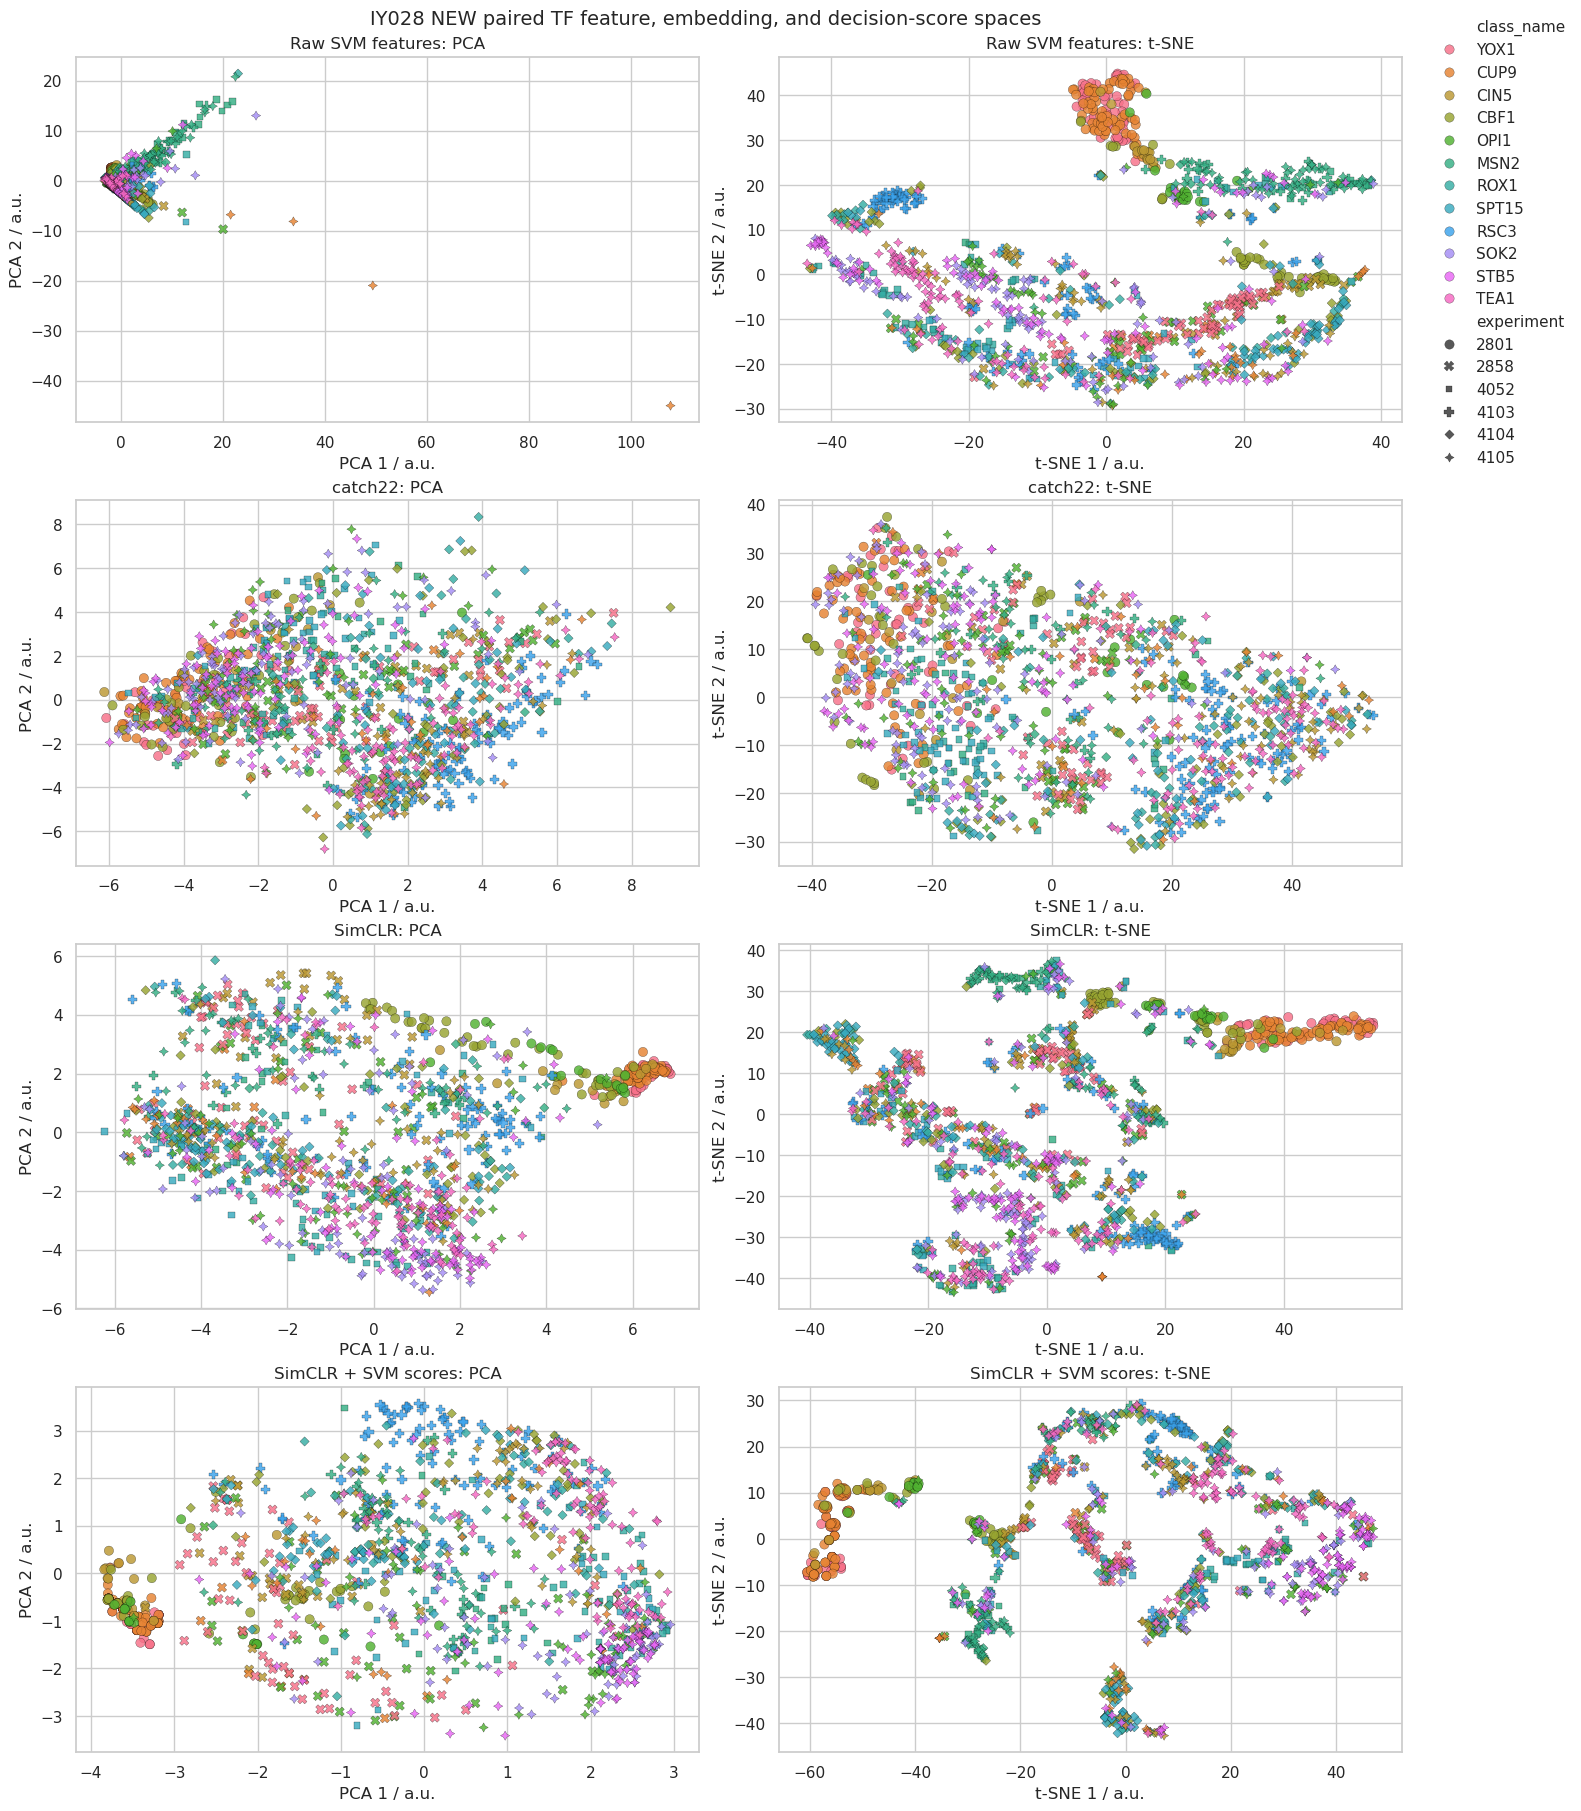

In [12]:
def projection_frame(coords, metadata, representation, method):
    """Combine 2D coordinates with cell metadata for plotting."""
    df = metadata.copy()
    df["x"] = coords[:, 0]
    df["y"] = coords[:, 1]
    df["representation"] = representation
    df["method"] = method
    return df


representation_order = ["Raw SVM features", "catch22", "SimCLR", "SimCLR + SVM scores"]
method_order = ["PCA", "t-SNE"]
# Build one long plotting table so every panel uses identical metadata columns.
plot_df = pd.concat(
    [
        projection_frame(projections[representation][method], metadata, representation, method)
        for representation in representation_order
        for method in method_order
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(
    len(representation_order),
    len(method_order),
    figsize=(14, 4.5 * len(representation_order)),
    constrained_layout=True,
)
axes = np.asarray(axes)

for row, representation in enumerate(representation_order):
    for col, method in enumerate(method_order):
        ax = axes[row, col]
        df_sub = plot_df[(plot_df["representation"] == representation) & (plot_df["method"] == method)]
        sns.scatterplot(
            data=df_sub,
            x="x",
            y="y",
            hue="class_name",
            style="experiment",
            s=45,
            alpha=0.82,
            linewidth=0.2,
            edgecolor="black",
            ax=ax,
        )
        ax.set_title(f"{representation}: {method}")
        ax.set_xlabel(f"{method} 1 / a.u.")
        ax.set_ylabel(f"{method} 2 / a.u.")
        # Remove per-panel legends; a single figure-level legend is added below.
        ax.legend_.remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
fig.suptitle("IY028 NEW paired TF feature, embedding, and decision-score spaces", fontsize=14)

out_path = IY028_DIR / "IY028_embedding_space_visualisation_NEW.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## Save Coordinates

In [13]:
coords_path = IY028_DIR / "IY028_embedding_space_coordinates_NEW.csv"
plot_df.to_csv(coords_path, index=False)
print(f"Saved: {coords_path}")
display(plot_df.head())

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_embedding_space_coordinates_NEW.csv


,cell_id,class_name,tf,group,experiment,source_key,label,x,y,representation,method
0,ch10_YOX1_001;0;1,YOX1,YOX1,ch10_YOX1,2801,2801_group_ch10_YOX1,2,-1.727410,2.001998,Raw SVM features,PCA
1,ch10_YOX1_001;10;1,YOX1,YOX1,ch10_YOX1,2801,2801_group_ch10_YOX1,2,-1.836435,2.073424,Raw SVM features,PCA
2,ch10_YOX1_001;11;1,YOX1,YOX1,ch10_YOX1,2801,2801_group_ch10_YOX1,2,-2.007929,2.239001,Raw SVM features,PCA
3,ch10_YOX1_001;15;2,YOX1,YOX1,ch10_YOX1,2801,2801_group_ch10_YOX1,2,-1.513057,2.028844,Raw SVM features,PCA
4,ch10_YOX1_001;15;6,YOX1,YOX1,ch10_YOX1,2801,2801_group_ch10_YOX1,2,-2.004267,2.551628,Raw SVM features,PCA


# NEXT STEPS

1. **Train and evaluate length-matched SimCLR.**
   Pretrain or fine-tune SimCLR on traces cropped/downsampled to the `_NEW` trace length so the encoder sees the same temporal support at evaluation time.
   Compare:
   - old SimCLR model on _NEW;
   - old data cropped to 18 timepoints then SimCLR;
   - SimCLR trained from scratch on 18-timepoint synthetic/experimental windows.

   This tests whether the failure is length mismatch versus biological/domain mismatch.

2. **Unsupervised fine-tune SimCLR on `_NEW`.**
   Continue contrastive training from the best IY024 checkpoint using all paired `_NEW` traces without labels, then rerun the same downstream SVM and embedding visualisations.
   - Use all paired _NEW traces without labels.
   - Continue contrastive training from the best IY024 checkpoint.
   - Keep downstream SVM evaluation fixed.
   - This is probably the cleanest adaptation experiment.

3. **Check channel contribution.**
   Run mCherry-only, GFP-only, and dual-channel ablations to test whether the paired-channel encoder is mixing useful GFP TF-specific signal with less-informative shared Msn2 dynamics.

4. **Try simpler short-sequence encoders.**
   For 18 timepoints, compare the Transformer backbone against compact alternatives such as a 1D CNN/TCN, GRU/LSTM, or MLP on raw concatenated traces.

5. **Use time-aware or resampled input.**
   Check whether `_NEW` and the old data differ in sampling interval or physical time span, and either resample them to a common time axis or include time information explicitly.

6. **Find more TF screening experimental data for testing**